In [42]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [43]:
import os
from datetime import datetime
import sys
sys.path.append("../")

In [44]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.SbAgent import SbAgent

### Create market making environment

In [45]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics


### Parameters

In [46]:
seed_value = 3 
global seed  
seed = seed_value

# Reset seeds for all randomness sources
np.random.seed(seed)
torch.manual_seed(seed)

In [47]:
max_inventory = 20

In [48]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [49]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 14.872283180889763


In [50]:
def get_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModelPartialInformation(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [51]:
as_env = get_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [52]:
as_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


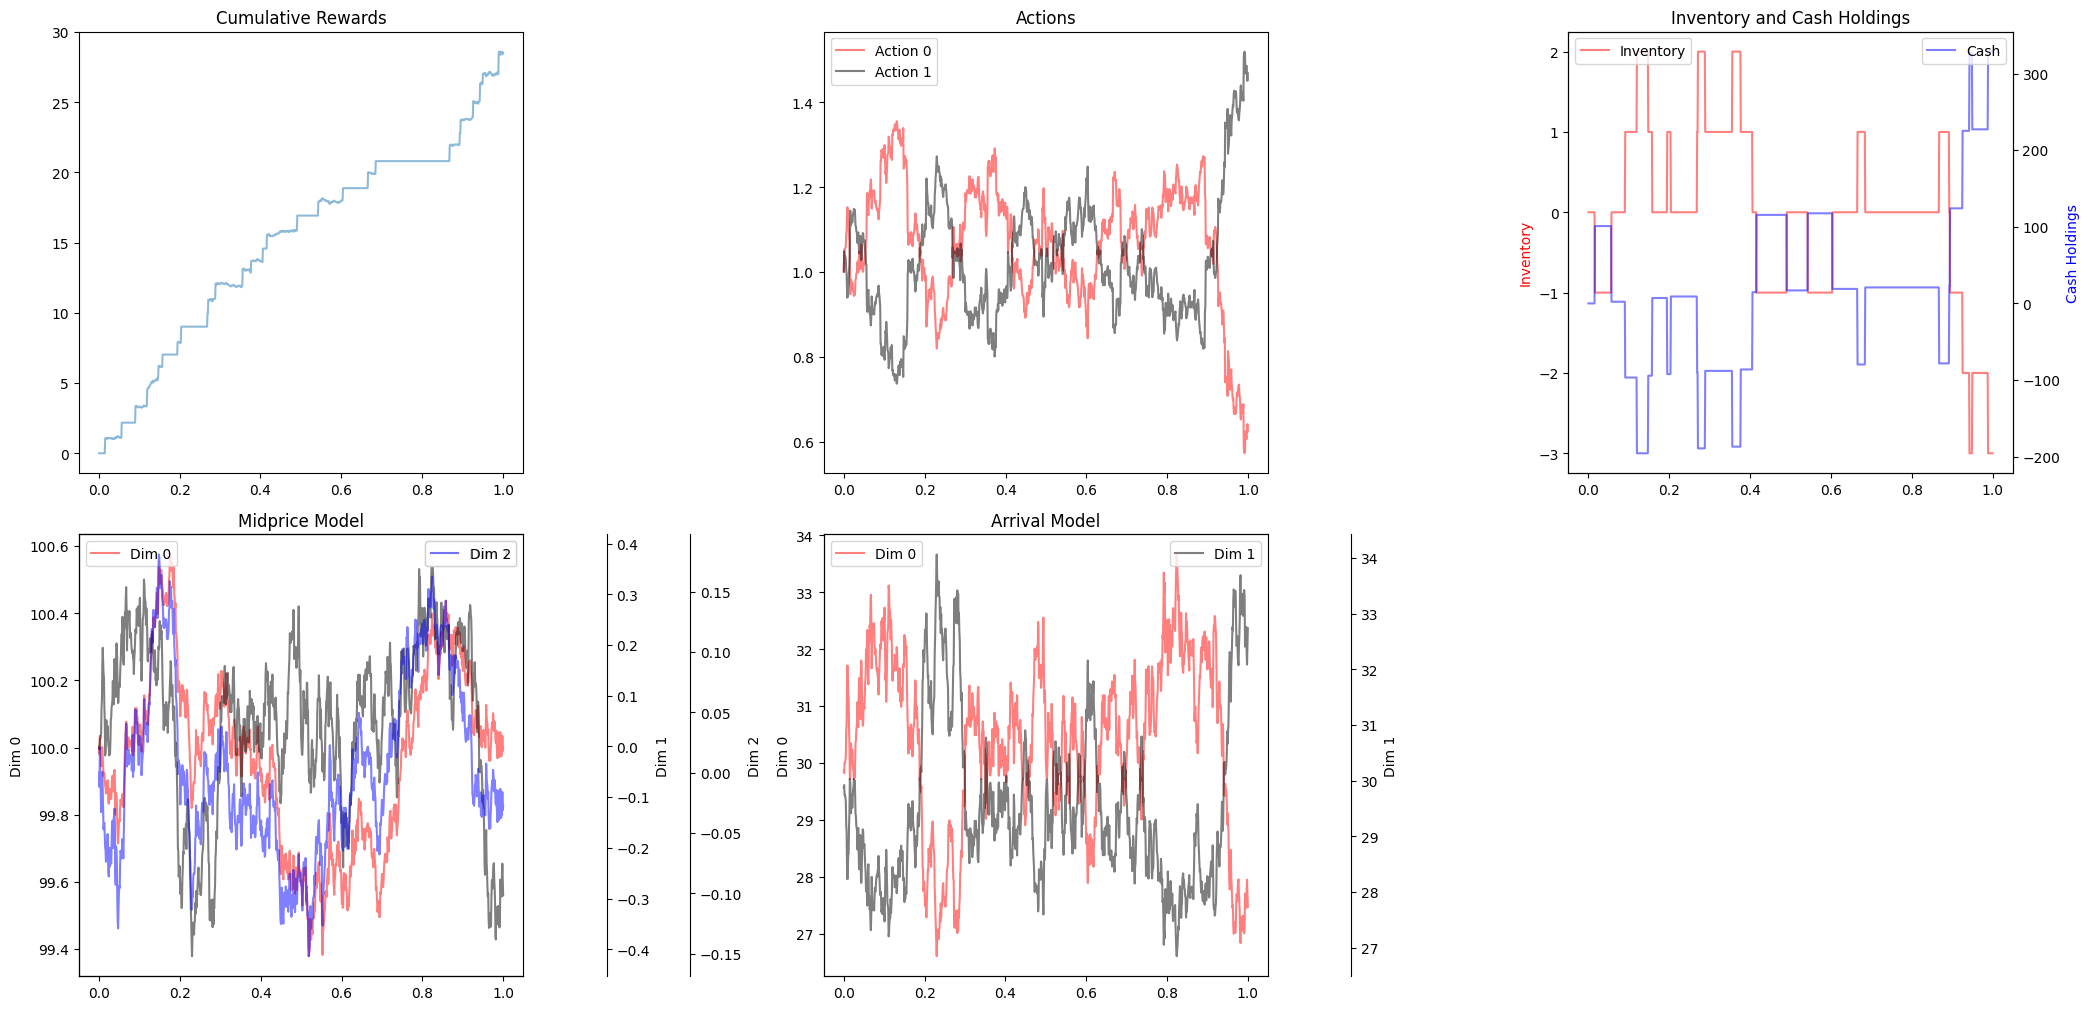

In [53]:
plot_trajectory_extended(as_env, as_agent)

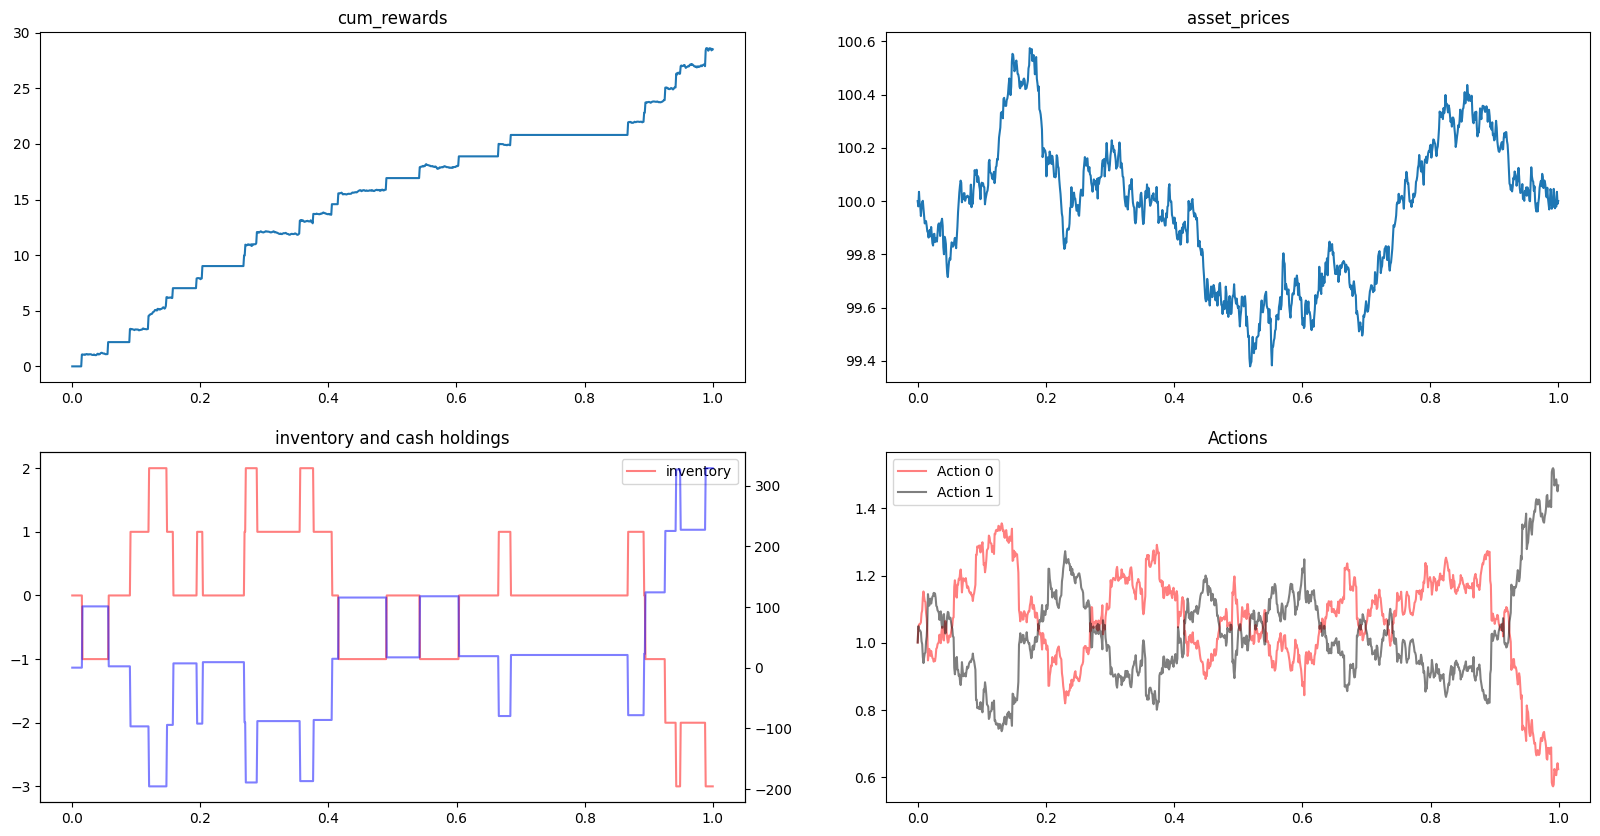

In [54]:
plot_trajectory(as_env, as_agent, seed = seed)

In [55]:
num_trajectories = 1000
vec_env = get_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)

print(vec_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [56]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUnifTraders_RL/../mbt_gym/agents/BaselineAgents.py:794: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


In [57]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [58]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.092579,21.292557,4.99465,0.053,2.289583


### Rinforncement Learning

In [59]:
num_trajectories = 1000
reduced_training_indices = [INVENTORY_INDEX,TIME_INDEX, ASSET_PRICE_INDEX, FADS_INDEX]
env = ReduceStateSizeWrapper(get_env(num_trajectories), reduced_training_indices)
#env = get_env(num_trajectories)
sb_env = StableBaselinesTradingEnvironment(trading_env=env)

In [60]:
# Monitor sb_env
sb_env = VecMonitor(sb_env)

# Generate timestamp string
run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Paths with timestamp
tensorboard_logdir = f"./Full_Info_models/tensorboard/PPO-learning-FI/{run_id}/"
best_model_path = f"./Full_Info_models/PPO-best-FI/"

In [61]:
# Make sure directories exist
os.makedirs(tensorboard_logdir, exist_ok=True)
os.makedirs(best_model_path, exist_ok=True)

In [62]:
# # Save the final model regardless of performance
# final_model_path = "./Baseline_models/PPO-final-model_30seconds"
# model.save(final_model_path)
# print(f"Final model saved to {final_model_path}")

In [63]:
policy_kwargs = dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])])
PPO_params = {"policy":'MlpPolicy', "env": sb_env, "verbose":1, 
              "policy_kwargs":policy_kwargs, 
              "tensorboard_log":tensorboard_logdir,
              "n_epochs":3,
              "batch_size": int(n_steps * num_trajectories / 10), 
              "n_steps": int(n_steps)}
callback_params = dict(eval_env=sb_env, n_eval_episodes = 2048, #200 before  (n_eval_episodes)
                       best_model_save_path = best_model_path, 
                       deterministic=True)

callback = EvalCallback(**callback_params)
model = PPO(**PPO_params, device="cpu")

Using cpu device


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


In [64]:
print(sb_env.observation_space)

Box([-20.          0.         -5.5999999 -10.       ], [ 20.           1.         105.59999847  10.        ], (4,), float64)


In [65]:
model.learn(total_timesteps = 30_000_000, callback=callback)  # Increase number of training timesteps according to computing resources

Logging to ./Full_Info_models/tensorboard/PPO-learning-FI/2025-10-03_11-16-55/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 5.78     |
| time/              |          |
|    fps             | 372318   |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1000000  |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | 6.66         |
| time/                   |              |
|    fps                  | 113260       |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 2000000      |
| train/                  |              |
|    approx_kl            | 0.0031478486 |
|    clip_fraction        | 0.0176       |
|    clip_range           | 0.2          |
|    entropy_loss

In [66]:
# model = PPO.load("./FI_models/PPO-final-model", env=sb_env)

In [67]:

ppo_agent = SbAgent(model, reduced_training_indices = reduced_training_indices)

Process name midprice_model
Start idx 3
End idx 6
Process name arrival_model
Start idx 6
End idx 8


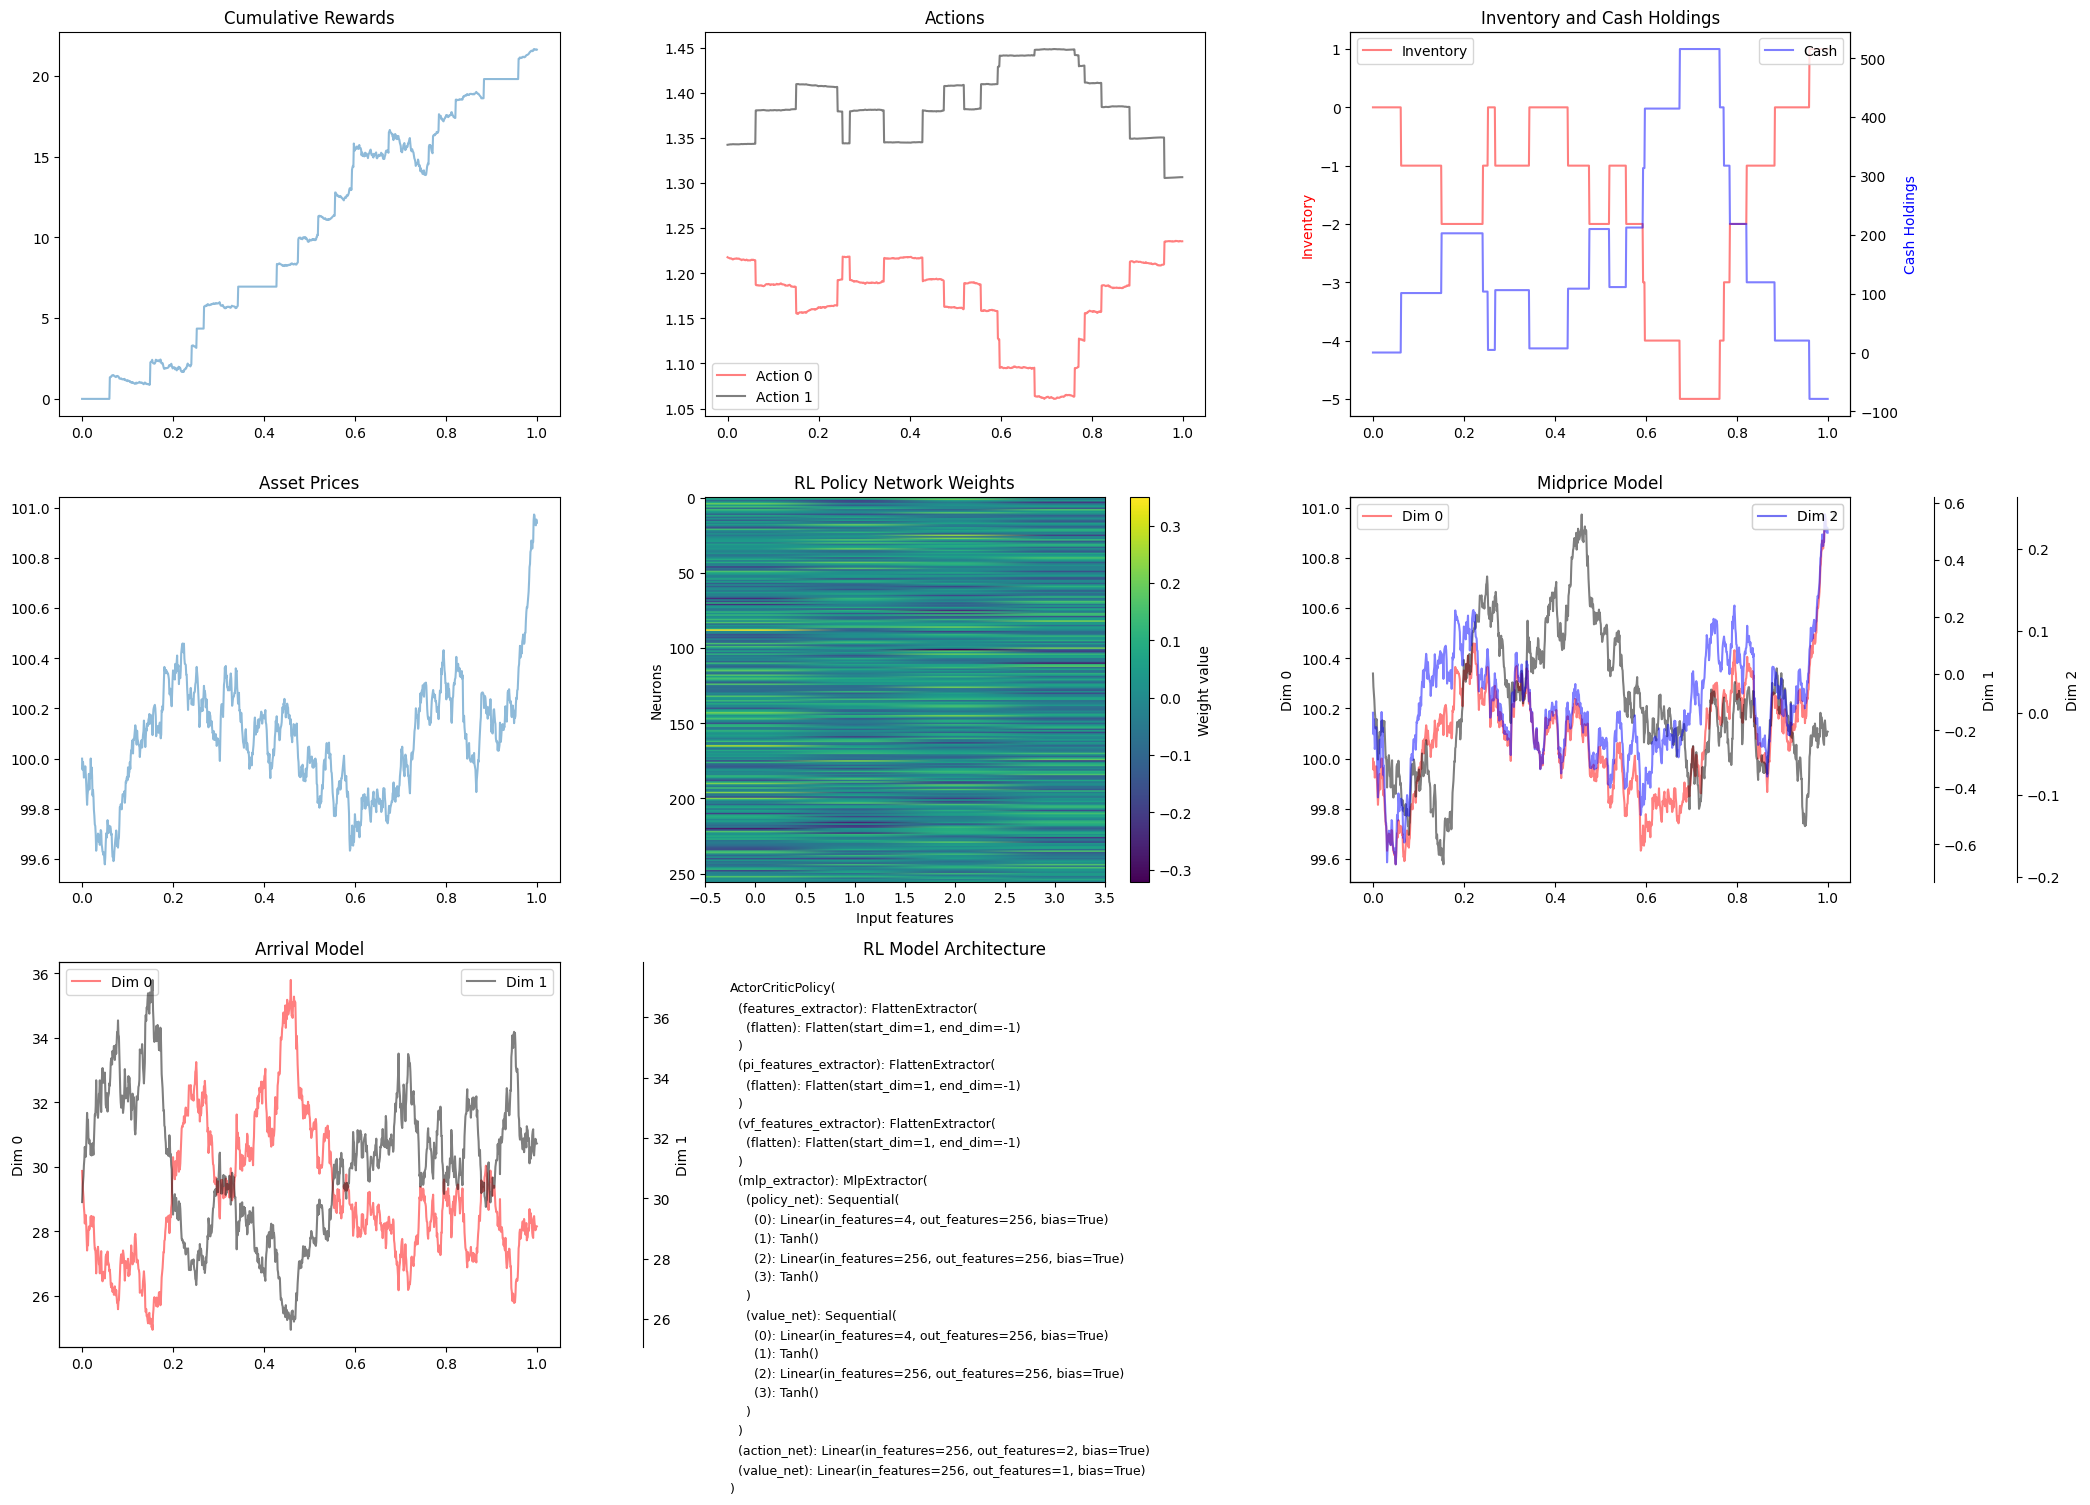

In [68]:
plot_rl_trajectory_extended(as_env, ppo_agent)

In [69]:
results, fig, total_rewards = generate_results_table_and_hist_rl(vec_env=vec_env, rl_agent=ppo_agent)

In [70]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
RL Agent,2.523782,20.586357,5.598911,0.662,3.229823


## Comparing the learnt policy to the optimal policy

In [71]:
from mbt_gym.agents.SbAgent import SbAgent

In [72]:
ppo_agent = SbAgent(model)

In [73]:
inventories = np.arange(-3,4,1)
bid_actions = []
ask_actions = []
for inventory in inventories:
    bid_action, ask_action = ppo_agent.get_action(np.array([[inventory,0.5,100,0]])).reshape(-1)
    bid_actions.append(bid_action)
    ask_actions.append(ask_action)    

In [74]:
#ppo_agent.get_action(np.array([[inventory,0.5]]))

In [75]:
full_info_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=get_env())

✓ Pre-computed ODE solutions for 1000 time points


In [76]:
# Get the Cartea Jaimungal action
cj_bid_actions = []
cj_ask_actions = []
for inventory in inventories:
    bid_action, ask_action = full_info_agent.get_action(np.array([[0,inventory,0.5,100,0]])).reshape(-1)
    cj_bid_actions.append(bid_action)
    cj_ask_actions.append(ask_action)

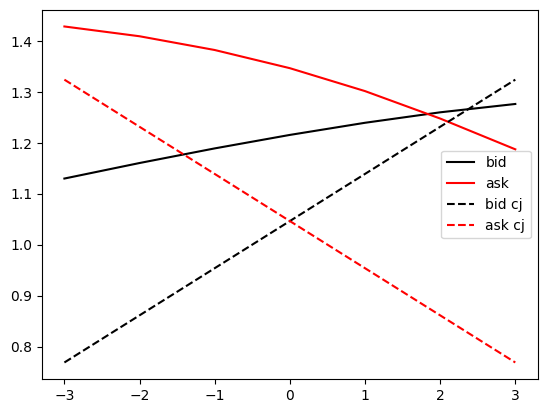

In [77]:
plt.plot(inventories, bid_actions, label = "bid", color = "k")
plt.plot(inventories, ask_actions, label = "ask", color = "r")
plt.plot(inventories, cj_bid_actions, label = "bid cj", color = "k", linestyle = "--")
plt.plot(inventories, cj_ask_actions, label = "ask cj", color = "r", linestyle = "--")
plt.legend()

## Dependence of policy on time

In [78]:
# Function to create the plot comparing PPO and closed approx agent
def plot_policy_time_dependence(ppo_agent, agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  # 0 to 30 seconds
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  # RL bid
    ax2 = plt.subplot(gs[0, 1])  # CJ bid
    ax3 = plt.subplot(gs[1, 0])  # RL ask
    ax4 = plt.subplot(gs[1, 1])  # CJ ask
    
    price = 100.0  # Fixed price for evaluation
    
    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        bids = []
        asks = []
        
        # For each time point
        for t in times:
            normalized_time = t/terminal_time  # Normalize time to [0,1]
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv, normalized_time, price, 0]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get agent's actions
            bid, ask = agent.get_action(np.array([[0, inv, normalized_time, price, 0]])).reshape(-1)
            bids.append(bid)
            asks.append(ask)
        
        # Plot the data
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, asks, label=f"Inventory = {inv}", color=colors[inv])
    
    # Setting titles and labels
    ax1.set_title("RL δ^bid")
    ax2.set_title("CJP δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("CJP δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    # Add a legend to the first subplot
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    # Add an overall figure caption
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()

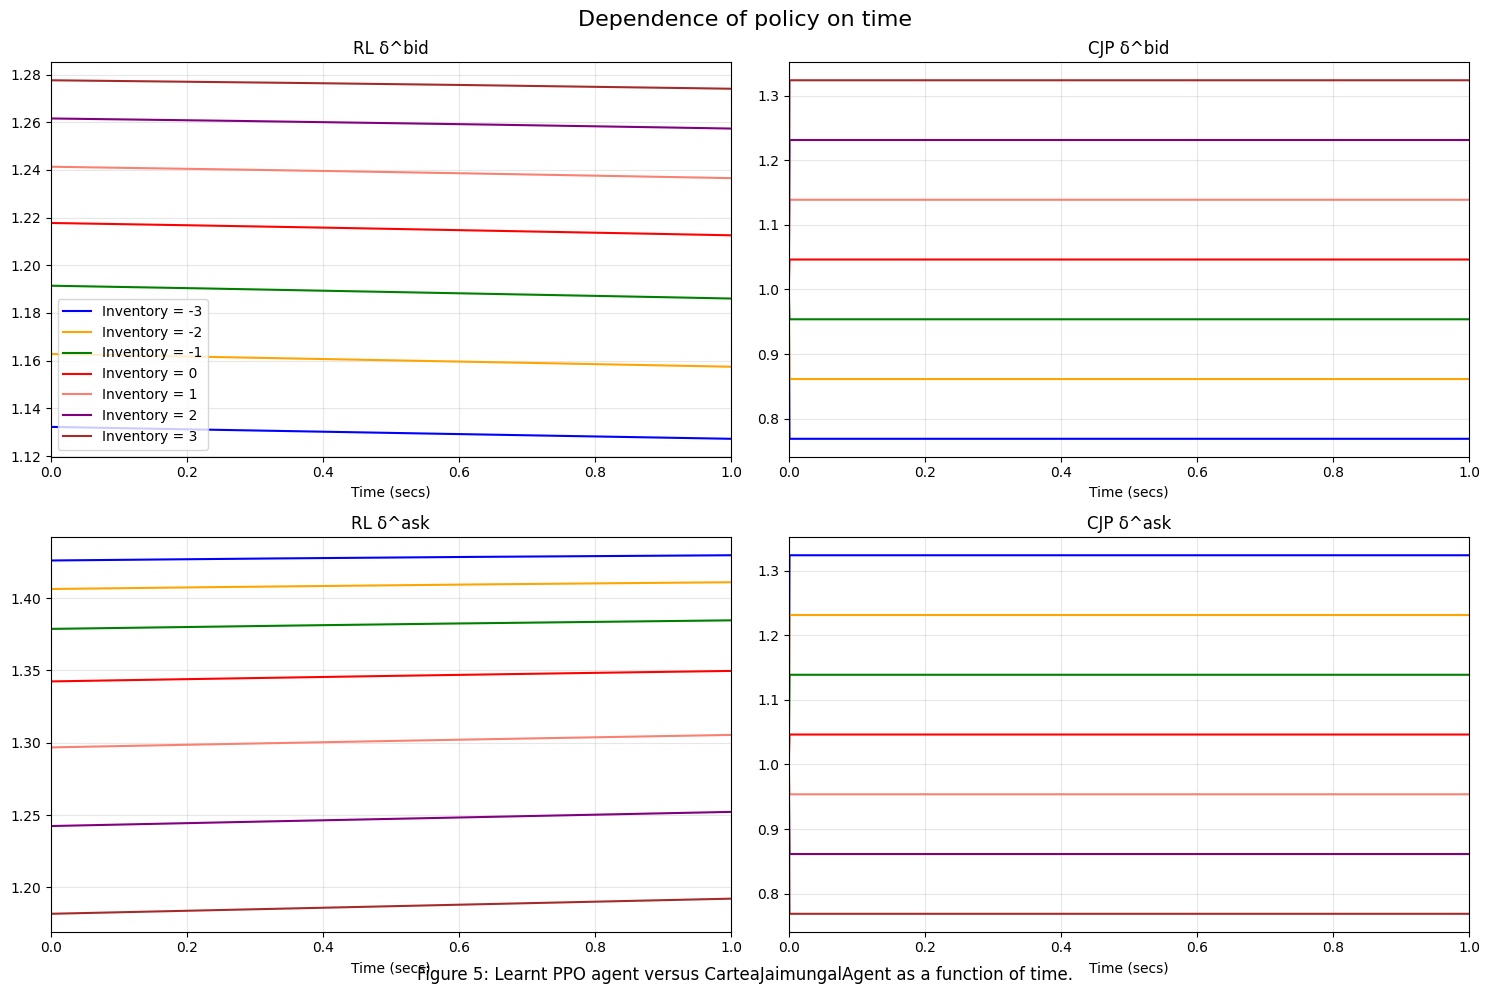

In [79]:
plot_policy_time_dependence(ppo_agent, full_info_agent)

In [80]:
def plot_policy_time_dependence(ppo_agent, agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  # RL bid
    ax2 = plt.subplot(gs[0, 1])  # CJ bid
    ax3 = plt.subplot(gs[1, 0])  # RL ask
    ax4 = plt.subplot(gs[1, 1])  # CJ ask
    
    price = 100.0  # Fixed price for evaluation
    
    # Track global min/max for all plots
    global_min = float('inf')
    global_max = float('-inf')
    
    # Store all data to plot later
    all_data = []
    
    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        bids = []
        asks = []
        
        # For each time point
        for t in times:
            normalized_time = t/terminal_time  # Normalize time to [0,1]
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv, normalized_time, price, 0]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get agent's actions
            bid, ask = agent.get_action(np.array([[0, inv, normalized_time, price, 0]])).reshape(-1)
            bids.append(bid)
            asks.append(ask)
        
        # Update global min/max
        global_min = min(global_min, min(rl_bids), min(rl_asks), min(bids), min(asks))
        global_max = max(global_max, max(rl_bids), max(rl_asks), max(bids), max(asks))
        
        # Store data for later plotting
        all_data.append((inv, rl_bids, rl_asks, bids, asks))
    
    # Now plot all data with the same y-axis scale
    for inv, rl_bids, rl_asks, bids, asks in all_data:
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, asks, label=f"Inventory = {inv}", color=colors[inv])
    
    # Apply the same y-axis limits to all subplots
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(global_min, global_max)
    
    # Setting titles and labels
    ax1.set_title("RL δ^bid")
    ax2.set_title("CJP δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("CJP δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    # Add a legend to the first subplot
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    # Add an overall figure caption
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()

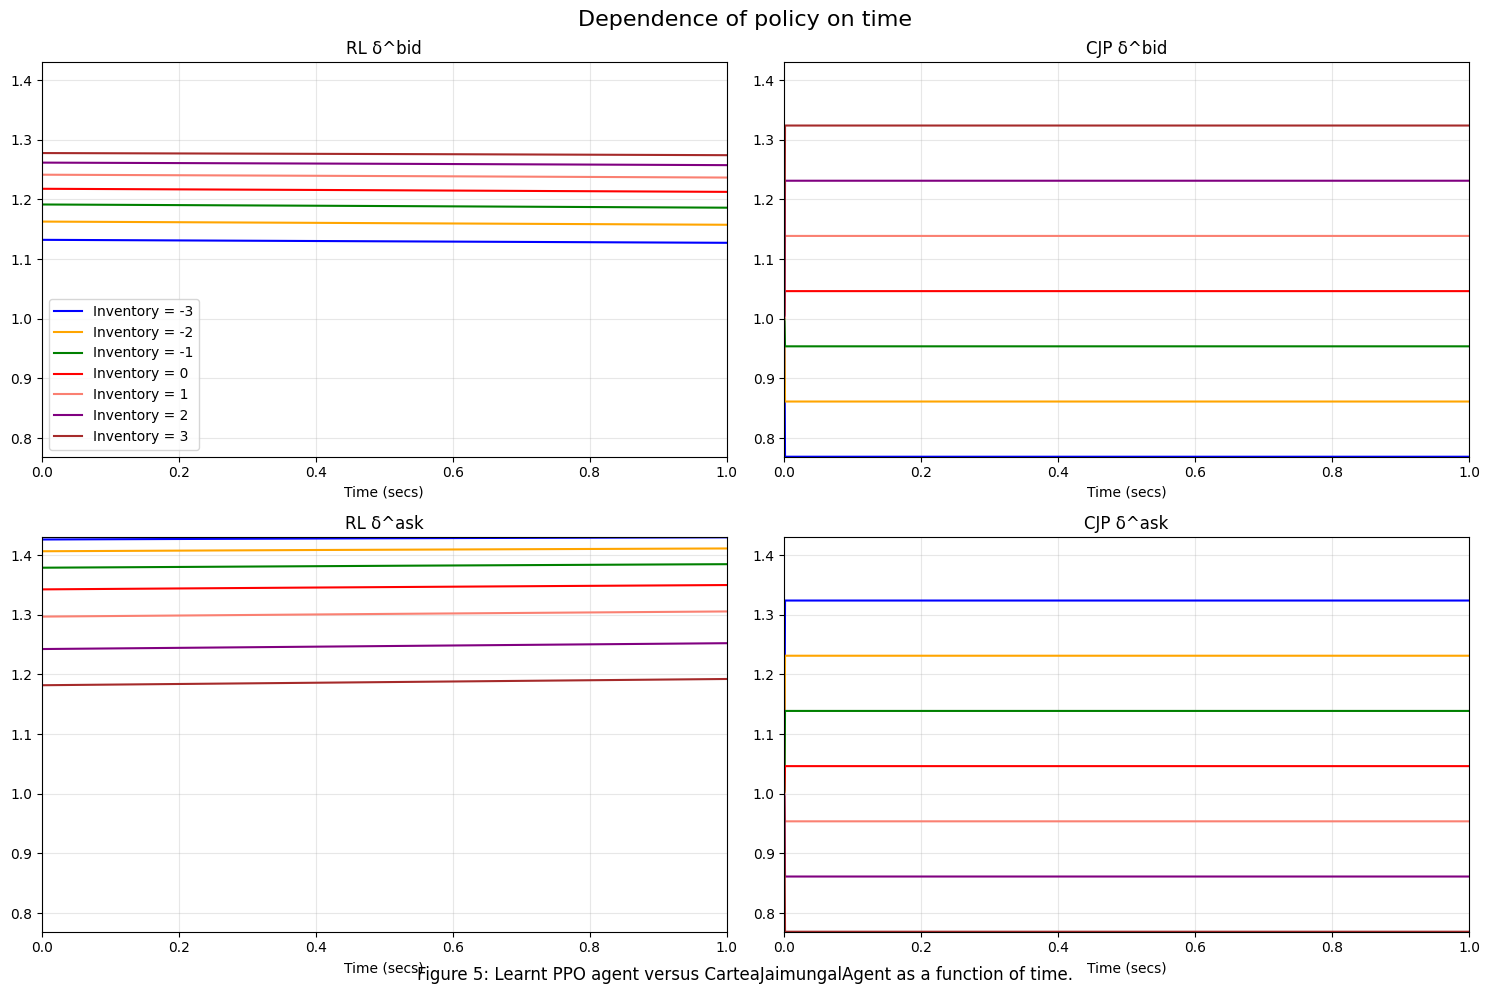

In [81]:
plot_policy_time_dependence(ppo_agent, full_info_agent)